# Common Complex Data Structure Examples

## Graphs

In [ ]:
# !pip install networkx

The **NetworkX** package provides classes for graph objects, generators to create standard graphs, IO routines for reading in existing datasets, algorithms to analyze the resulting networks and some basic drawing tools.

A online documentation can be found from https://networkx.org/documentation/stable/reference/index.html

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

### Create a directed graph

In [3]:
# Create a directed graph
G = nx.DiGraph()
# Add nodes
G.add_node(1)
G.add_node(2)
G.add_node(3)
G.add_node(4)
G.add_node(5)
G.add_node(6)
# Add edges
G.add_edge(1, 2)
G.add_edge(2, 3)
G.add_edge(3, 4)
G.add_edge(4, 1)
G.add_edge(1, 4)
G.add_edge(4, 5)
G.add_edge(5, 6)

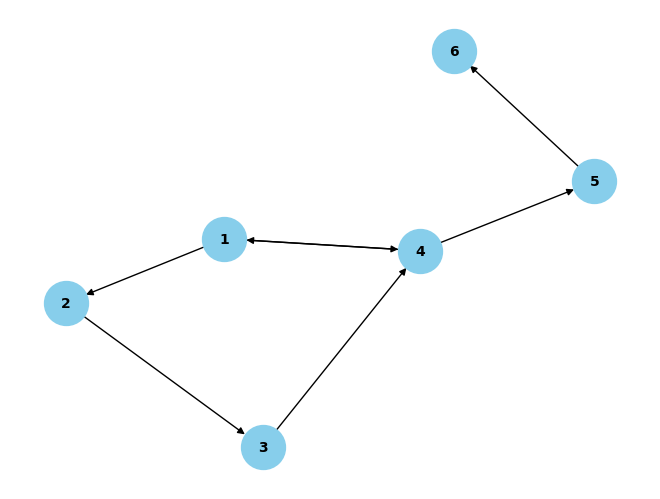

In [4]:
# plot the graph
nx.draw(G, with_labels=True, node_size=1000, node_color="skyblue", font_size=10, font_color="black", font_weight="bold")
# show the plot
plt.show()

In [5]:
# calculate the path between two nodes
for shortest_path in nx.all_shortest_paths(G, 1, 5):
    print('Shortest path between 1 and 5: ', shortest_path)

    # calculate the shortest path length
    print('Shortest path length between 1 and 5: ', len(shortest_path) - 1)
# or using built-in function
print('Shortest path length between 1 and 5: ',nx.shortest_path_length(G, 1, 5))

Shortest path between 1 and 5:  [1, 4, 5]
Shortest path length between 1 and 5:  2
Shortest path length between 1 and 5:  2


### Create a indirected graph

In [6]:
# build a in-directed graph
G = nx.Graph(directed=False)
G.add_node(1)
G.add_node(2)
G.add_node(3)
G.add_node(4)
G.add_node(5)
G.add_node(6)
# Add edges
G.add_edge(1, 2)
G.add_edge(2, 3)
G.add_edge(3, 4)
G.add_edge(4, 1)
G.add_edge(4, 5)
G.add_edge(5, 6)

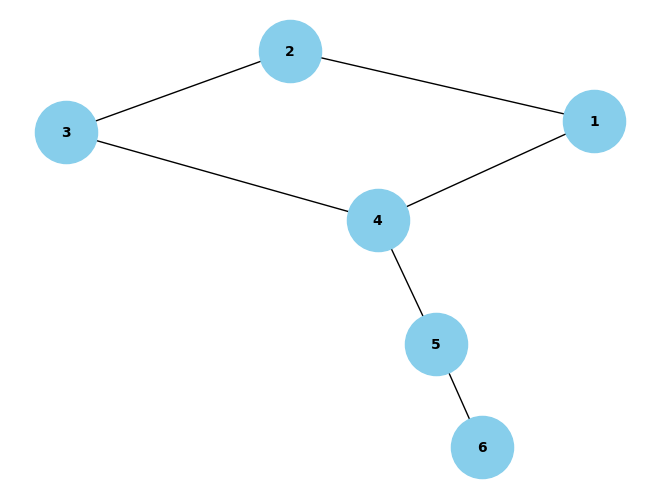

In [7]:
# plot the graph
nx.draw(G, with_labels=True, node_size=2000, node_color="skyblue", font_size=10, font_color="black", font_weight="bold")
# show the plot
plt.show()

In [8]:
# calculate the path between two nodes
for possible_path in nx.all_simple_paths(G, 2, 5):
    print('Possible path between 2 and 5: ', possible_path)
    # calculate path length
    print('Path length between 2 and 5: ', len(possible_path)-1)

Possible path between 2 and 5:  [2, 1, 4, 5]
Path length between 2 and 5:  3
Possible path between 2 and 5:  [2, 3, 4, 5]
Path length between 2 and 5:  3


### Weighted Indirected Graph

In above case, there are exist two shortest path between node 2 and 5 which are 2->1->4->5 and 2->3->4->5.

This based on the assumption that all the path with save weight. In this example, we can adjust the weight of the edge between node 1 and 2 or 2 and 3, then see the result.

In [9]:
# Build a weighted graph
G = nx.Graph()
G.add_node(1)
G.add_node(2)
G.add_node(3)
G.add_node(4)
G.add_node(5)
G.add_node(6)
# Add weighted edges
G.add_edge(1, 2, weight=1)
# adjust the weight of the edge between 2 and 3
G.add_edge(2, 3, weight=3)
G.add_edge(3, 4, weight=1)
G.add_edge(4, 1, weight=1)
G.add_edge(4, 5, weight=1)
G.add_edge(5, 6, weight=1)
# add weight to the edge between 2 and 5

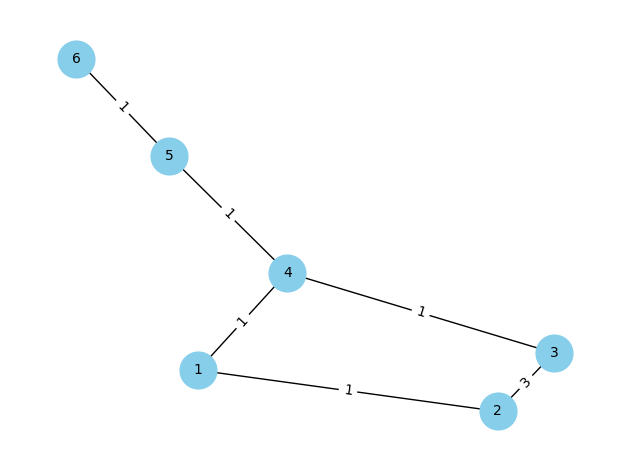

In [10]:
# plot the graph

# positions for all nodes - seed for reproducibility
pos = nx.spring_layout(G, seed=7)

# nodes
nx.draw_networkx_nodes(G, pos, node_size=700, node_color = "skyblue")

# edges
nx.draw_networkx_edges(G, pos)



# node labels
nx.draw_networkx_labels(G, pos, font_size=10, font_family="sans-serif")
# edge weight labels
edge_labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, pos, edge_labels)

ax = plt.gca()
ax.margins(0.08)
plt.axis("off")
plt.tight_layout()

# show the plot
plt.show()

In [11]:
# calculate the shortest path between two nodes
for shortest_path in nx.all_shortest_paths(G, 2, 5, weight='weight'):
    print('Shortest path between 2 and 5: ', shortest_path)
    # calculate the shortest path length
    print('Shortest path length between 2 and 5: ', len(shortest_path) - 1)

Shortest path between 2 and 5:  [2, 1, 4, 5]
Shortest path length between 2 and 5:  3


## Trees

Trees are a type of graph with a hierarchical structure, consisting of a root node and child nodes,
with no cycles.

- General Trees
- Binary Trees
- Binary Search Trees (BST)
- B-Trees

### General Trees

[AnyTree](https://anytree.readthedocs.io/en/latest/) is a library designed to provide data structures and operations for storing and manipulating tree structures.

In [ ]:
# !pip install anytree

In [13]:
from anytree import Node, RenderTree

In [14]:
root = Node("root")
a = Node("a", parent=root)
b = Node("b", parent=root)
a1 = Node("a1", parent=a)
a2 = Node("a2", parent=a)
b1 = Node("b1", parent=b)
c = Node("c", parent=root)
c1 = Node("c1", parent=c)

for pre, fill, node in RenderTree(root):
    print("%s%s" % (pre, node.name))

root
├── a
│   ├── a1
│   └── a2
├── b
│   └── b1
└── c
    └── c1


[`Binarytree`](https://pypi.org/project/binarytree/) is a Python library which lets you generate, visualize, inspect and manipulate binary trees.

In this notebook, we will explore the `binarytree` library and its features.

In [15]:
!pip install binarytree

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [binarytree]


### Binary Trees

In [16]:
from binarytree import tree, bst, build, Node

#### Random Binary Tree

In [17]:
# seed for reproducibility
import random
random.seed(6915)
# Generate a random binary tree and return its root node.
random_tree_2 = tree(height=2, is_perfect=False)
print(random_tree_2)


  __5__
 /     \
4       6
 \     / \
  3   0   1



In [18]:
# Generate a perfect random binary tree and return its root node.
random_tree_2 = tree(height=2, is_perfect=True)
print(random_tree_2)


    __1__
   /     \
  3       2
 / \     / \
4   5   6   0



With more elements.

In [19]:
random_tree_3 = tree(height=3, is_perfect=False)
print(random_tree_3)


      0___
     /    \
  __9     _2
 /       /  \
6       14   3
 \            \
  8            11



### Binary Search Trees (BST)

In [20]:
binary_search_tree = bst(height=2, is_perfect=True)
print(binary_search_tree)


    __3__
   /     \
  1       5
 / \     / \
0   2   4   6



In [21]:
binary_search_tree = bst(height=3, is_perfect=True)
print(binary_search_tree)


        ______7_______
       /              \
    __3__           ___11___
   /     \         /        \
  1       5       9         _13
 / \     / \     / \       /   \
0   2   4   6   8   10    12    14



### Build a Binary Tree

#### Build from Node

In [22]:
root = Node(1)
root.left = Node(5)
root.right = Node(9)
root.left.right = Node(6)
print(root)


  __1
 /   \
5     9
 \
  6



##### Insertion

In [23]:
root.left.left = Node(10)

print(root)


     __1
    /   \
  _5     9
 /  \
10   6



#### Build from list

In [24]:
values = [4, 3, 2, 6, 0, None, 1, 5, 8]
tree_from_list = build(values)
print(tree_from_list)


        __4
       /   \
    __3     2
   /   \     \
  6     0     1
 / \
5   8

